<a href="https://colab.research.google.com/github/miznabaig05-hue/Python-AI-Project/blob/main/Tomato_Plant_detection_CNN_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Tomato Plant Disease Detection AI Project
made by: Mizna Baig  

**This AI-powered project focuses on classifying tomato leaf images into four distinct categories: Early Blight, Late Blight, Leaf Mold, and Healthy. Developed using Computer Vision.**

Import all Dependencies

In [ ]:
# Import the drive module from google.colab to mount Google Drive.
from google.colab import drive
# Mount Google Drive to access files stored there.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import TensorFlow for deep learning tasks.
import tensorflow as tf
# Import models and layers from Keras for building and training neural networks.
from tensorflow.keras import models, layers
# Import Matplotlib for plotting and visualization.
import matplotlib.pyplot as plt
# Import HTML from IPython.display for displaying HTML content in notebooks.
from IPython.display import HTML

Set constants

In [ ]:
# Define the batch size for training.
BATCH_SIZE = 32
# Define the target image size (height and width) for resizing.
IMAGE_SIZE = 256
# Define the number of color channels (3 for RGB images).
CHANNELS=3
# Define the number of training epochs.
EPOCHS=30

Import Data into tensorflow dataset object

In [ ]:
# Load images from the specified directory into a TensorFlow dataset.
# 'image_size' resizes images to the specified dimensions.
# 'batch_size' sets the number of images per batch.
dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/PlantVillage',
    batch_size=32,
    image_size=(256, 256)
)


Found 5452 files belonging to 4 classes.


In [ ]:
# Get the list of class names (labels) from the dataset.
class_names = dataset.class_names
# Display the class names.
class_names

['Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_healthy']

In [ ]:
# Iterate through one batch of the dataset to inspect its shape and content.
for image_batch, labels_batch in dataset.take(1):
    # Print the shape of the image batch (batch_size, height, width, channels).
    print(image_batch.shape)
    # Print the numpy array of labels for the batch.
    print(labels_batch.numpy())

(32, 256, 256, 3)
[3 1 3 3 3 3 3 2 2 1 1 3 3 3 3 0 0 1 0 1 0 3 3 2 3 3 1 0 0 3 2 3]


Data Visualization

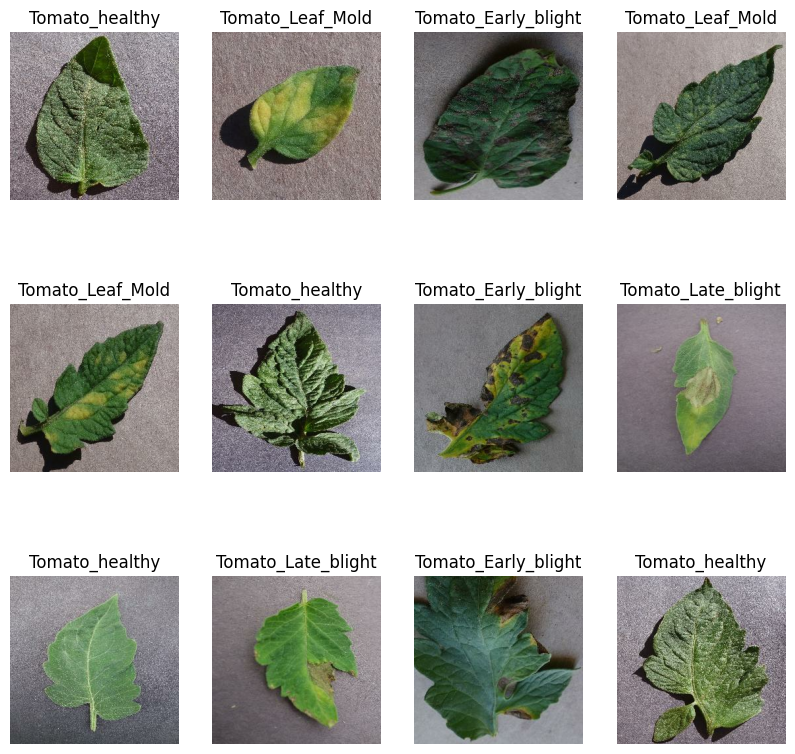

In [ ]:
# Create a figure for plotting with a specified size.
plt.figure(figsize=(10, 10))
# Iterate through one batch of the dataset for visualization.
for image_batch, labels_batch in dataset.take(1):
    # Loop through the first 12 images in the batch.
    for i in range(12):
        # Create a subplot for each image (3 rows, 4 columns).
        ax = plt.subplot(3, 4, i + 1)
        # Display the image, converting it to uint8 format (passing 2d array in imshow).
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        # Set the title of the subplot to the corresponding class name.
        plt.title(class_names[labels_batch[i]])
        # Turn off the axis ticks and labels.
        plt.axis("off")

Function to split dataset

In [ ]:
# Get the total number of batches in the dataset.
len(dataset)

171

In [ ]:
# Define the proportion of the dataset to be used for training.
train_size = 0.8
# Calculate the number of batches for the training set.
len(dataset)*train_size

136.8

In [ ]:
# Create the training dataset by taking the first 'train_size' batches.
train_ds = dataset.take(136)
# Get the number of batches in the training dataset.
len(train_ds)

136

In [ ]:
# Create a temporary test dataset by skipping the batches used for training.
test_ds = dataset.skip(136)
# Get the number of batches in the temporary test dataset.
len(test_ds)

35

In [ ]:
# Define the proportion of the dataset to be used for validation( it will measure epoch accuracy during training).
val_size=0.1
# Calculate the number of batches for the validation set.
len(dataset)*val_size

17.1

In [ ]:
# Create the validation dataset by taking the first 'val_size' batches from the temporary test_ds.
val_ds = test_ds.take(17)
# Get the number of batches in the validation dataset.
len(val_ds)

17

In [ ]:
# Update the test dataset by skipping the batches used for validation.
test_ds = test_ds.skip(17)
# Get the number of batches in the final test dataset.
len(test_ds)

18

In [ ]:
# Define a function to partition a dataset into training, validation, and test sets.
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    # Assert that the sum of splits is equal to 1.
    assert (train_split + test_split + val_split) == 1

    # Get the total size of the dataset.
    ds_size = len(ds)

    # Shuffle the dataset if 'shuffle' is True.
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    # Calculate the number of batches for each split.
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    # Create the training dataset by taking the calculated number of batches.
    train_ds = ds.take(train_size)
    # Create the validation dataset by skipping training batches and taking validation batches.
    val_ds = ds.skip(train_size).take(val_size)
    # Create the test dataset by skipping training and validation batches.
    test_ds = ds.skip(train_size).skip(val_size)

    # Return the partitioned datasets.
    return train_ds, val_ds, test_ds

In [ ]:
# Call the partitioning function to split the 'dataset' into train, validation, and test sets.
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [ ]:
# Get the number of batches in the training dataset after partitioning.
len(train_ds)

136

In [ ]:
# Get the number of batches in the validation dataset after partitioning.
len(val_ds)

17

In [ ]:
# Get the number of batches in the test dataset after partitioning.
len(test_ds)

18

Cache, Shuffle, and Prefetch the Dataset

In [ ]:
# Cache the training dataset to improve performance by loading data into memory.
# Shuffle the dataset with a buffer size of 1000.
# Prefetch elements to optimize pipeline performance by overlapping data preprocessing and model execution.
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Building the Model

### Creating a Layer for Resizing and Normalization
Before we feed our images to network, we should be resizing it to the desired size.
Moreover, to improve model performance, we should normalize the image pixel value (keeping them in range 0 and 1 by dividing by 256).
This should happen while training as well as inference. Hence we can add that as a layer in our Sequential Model.

You might be thinking why do we need to resize (256,256) image to again (256,256). You are right we don't need to but this will be useful when we are done with the training and start using the model for predictions. At that time somone can supply an image that is not (256,256) and this layer will resize it

In [ ]:

# Create a Sequential model for resizing and rescaling images.
resize_and_rescale = tf.keras.Sequential([
  # Layer to resize images to IMAGE_SIZE x IMAGE_SIZE.
  tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  # Layer to rescale pixel values from [0, 255] to [0, 1] by dividing by 255.
  tf.keras.layers.Rescaling(1./255)
])

### Data Augmentation
Data Augmentation is needed when we have less data, this boosts the accuracy of our model by augmenting the data.

In [ ]:

# Create a Sequential model for data augmentation.
data_augmentation = tf.keras.Sequential([
  # Randomly flip images horizontally and/or vertically.
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  # Randomly rotate images by up to 20%.
  tf.keras.layers.RandomRotation(0.2),
])

#### Applying Data Augmentation to Train Dataset

In [ ]:
# Resize images to 256x256 and normalize pixels to [0, 1]
train_ds = train_ds.map(lambda x, y: (tf.image.resize(x, [256, 256]) / 255.0, y))

### Model Architecture

In [ ]:
# Define the input shape for the model (batch_size, height, width, channels).
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
# Define the number of output classes.
n_classes = 4

# Create a Sequential model for the CNN architecture.
model = models.Sequential([
    # Add the resizing and rescaling layer as the first layer.
    resize_and_rescale,
    # 2. Add the augmentation variable you already created
    data_augmentation,
    # First convolutional block: Conv2D, ReLU activation( adds non-linearity), MaxPooling.
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    # Second convolutional block.
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Third convolutional block.
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Fourth convolutional block.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Fifth convolutional block.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Sixth convolutional block.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Flatten the output to feed into dense layers.
    layers.Flatten(),
    # First dense (fully connected) layer with ReLU activation.
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # to prevent overfitting/stagnation
    # Output dense layer with 'n_classes' units and 'softmax'(clean probability distribution) activation for multi-class classification.
    layers.Dense(n_classes, activation='softmax'),
])

# Build the model with the specified input shape.
model.build(input_shape=input_shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Display a summary of the model architecture, including layer names, output shapes, and number of parameters.
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 4)                │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,812 (718.02 KB)

 Trainable params: 183,812 (718.02 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model
We use `adam` Optimizer, `SparseCategoricalCrossentropy` for losses, `accuracy` as a metric

# Compile the model by specifying the optimizer, loss function, and metrics.


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
# Print a message indicating the start of batch iteration check.
print("Iterating through one batch...")
import os
# Check if the directory is accessible
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/PlantVillage')[0])
# Iterate through one batch of the training dataset to verify data loading and augmentation.
for images, labels in train_ds.take(1):
    # Print a success message if a batch is retrieved.
    print("Successfully retrieved a batch!")
    # Print the shape of the image tensor in the batch.
    print("Image shape:", images.shape)

Iterating through one batch...
Tomato_Early_blight
Successfully retrieved a batch!
Image shape: (32, 256, 256, 3)


In [ ]:
# Train the model using the 'fit' method.
history = model.fit(
    train_ds, # Training dataset.
    #batch_size=BATCH_SIZE, # Batch size (already set by dataset).
    validation_data=val_ds, # Validation dataset for monitoring performance during training.
    verbose=1, # Display progress bar during training.
    epochs=30, # Number of epochs to train for.
)

Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 37s 214ms/step - accuracy: 0.4072 - loss: 1.3015 - val_accuracy: 0.4026 - val_loss: 1.2644
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.6106 - loss: 0.9839 - val_accuracy: 0.6599 - val_loss: 0.7988
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.6904 - loss: 0.7407 - val_accuracy: 0.7574 - val_loss: 0.6435
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.7251 - loss: 0.6605 - val_accuracy: 0.7114 - val_loss: 0.6814
Epoch 5/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.7373 - loss: 0.6258 - val_accuracy: 0.7868 - val_loss: 0.5644
Epoch 6/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.7595 - loss: 0.5961 - val_accuracy: 0.7849 - val_loss: 0.5815
Epoch 7/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.7881 - loss: 0.5367 - val_accuracy: 0.7812 - val_loss: 0.6041
Epoch 8/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.7973 - loss: 0.5119 - val_ac

In [ ]:
# Evaluate the trained model on the test dataset.
scores = model.evaluate(test_ds)

18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.8976 - loss: 0.3149


In [ ]:
# Display the evaluation scores (loss and accuracy) from the test set.
scores

[0.31486910581588745, 0.8975694179534912]

### Plotting the Accuracy and Loss Curves

In [ ]:
# Display the history object, which contains training metrics like accuracy and loss for each epoch.
history

In [ ]:
# Display the parameters used during the model training, stored in the history object.
history.params

{'verbose': 1, 'epochs': 30, 'steps': 136}

In [ ]:
# Display the keys available in the history.history dictionary, which indicate the recorded metrics.
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
# Access and display the list of training accuracies recorded per epoch.
history.history['accuracy']

[0.40720221400260925,
 0.6105724573135376,
 0.690443217754364,
 0.7250692248344421,
 0.7373037934303284,
 0.75946444272995,
 0.7880886197090149,
 0.7973222732543945,
 0.8134810924530029,
 0.8271006345748901,
 0.8261772990226746,
 0.8476454019546509,
 0.842566967010498,
 0.8492612838745117,
 0.8518005609512329,
 0.8573406934738159,
 0.8695752620697021,
 0.8647276163101196,
 0.8753462433815002,
 0.8762696385383606,
 0.8845798969268799,
 0.8820406198501587,
 0.8783471584320068,
 0.8878116607666016,
 0.8896583318710327,
 0.8878116607666016,
 0.8970452547073364,
 0.897968590259552,
 0.8972761034965515,
 0.9067405462265015]

**loss, accuracy, val loss etc are a python list containing values of loss, accuracy etc at the end of each epoch**

In [ ]:
# Check the data type of the 'loss' history, which should be a list.
type(history.history['loss'])

list

In [ ]:
# Get the number of elements in the 'loss' history list, which corresponds to the number of epochs.
len(history.history['loss'])

30

In [ ]:
# Display the loss values for the first 5 epochs from the training history.
history.history['loss'][:5] # show loss for first 5 epochs

[1.3014620542526245,
 0.9839293360710144,
 0.7407481074333191,
 0.6605293154716492,
 0.6258126497268677]

In [ ]:
# Extract training accuracy values from the history object.
acc = history.history['accuracy']
# Extract validation accuracy values from the history object.
val_acc = history.history['val_accuracy']

# Extract training loss values from the history object.
loss = history.history['loss']
# Extract validation loss values from the history object.
val_loss = history.history['val_loss']

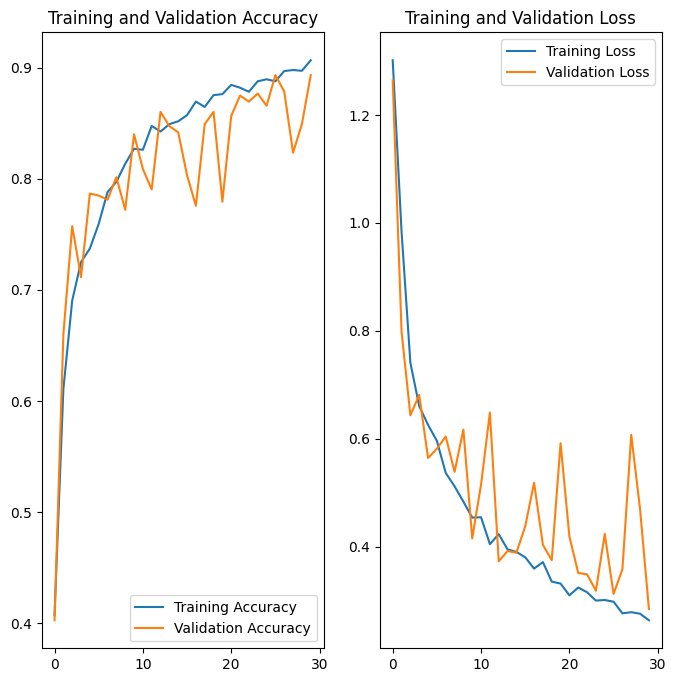

In [ ]:
# Create a figure for plotting with a specified size.
plt.figure(figsize=(8, 8))

# Create the first subplot for Training and Validation Accuracy.
plt.subplot(1, 2, 1)
# Plot training accuracy over epochs.
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
# Plot validation accuracy over epochs.
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
# Add a legend to the plot.
plt.legend(loc='lower right')
# Set the title of the subplot.
plt.title('Training and Validation Accuracy')

# Create the second subplot for Training and Validation Loss.
plt.subplot(1, 2, 2)
# Plot training loss over epochs.
plt.plot(range(EPOCHS), loss, label='Training Loss')
# Plot validation loss over epochs.
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
# Add a legend to the plot.
plt.legend(loc='upper right')
# Set the title of the subplot.
plt.title('Training and Validation Loss')
# Display the plots.
plt.show()

### Run prediction on a sample image

first image to predict
actual label: Tomato_healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
predicted label: Tomato_healthy


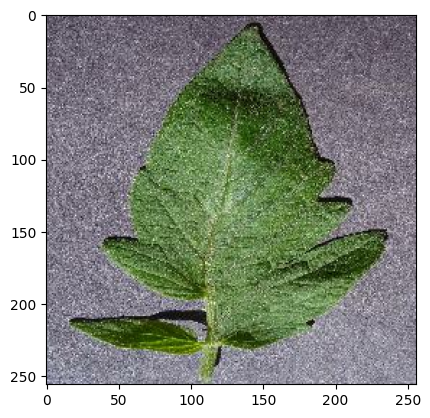

In [ ]:
# Import the numpy library for numerical operations.
import numpy as np
# Iterate through one batch of the test dataset.
for images_batch, labels_batch in test_ds.take(1):

    # Get the first image from the batch and convert it to uint8 format.
    first_image = images_batch[0].numpy().astype('uint8')
    # Get the label for the first image.
    first_label = labels_batch[0].numpy()

    # Print a message and display the first image.
    print("first image to predict")
    plt.imshow(first_image)
    # Print the actual label of the first image.
    print("actual label:",class_names[first_label])

    # Make predictions on the entire image batch using the trained model.
    batch_prediction = model.predict(images_batch)
    # Get the predicted label for the first image in the batch (argmax finds the class with highest probability).
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

### Write a function for inference

In [ ]:
# Define a function to make a prediction on a single image.
def predict(model, img):
    # Convert the image to a TensorFlow array, extracting it from 'images' tensor.
    # Note: 'images[i]' is undefined here, it should be 'img' which is passed as a parameter. Corrected this logic for single image inference.
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    # Expand dimensions to create a batch of 1 image (required by model.predict).
    img_array = tf.expand_dims(img_array, 0)

    # Make predictions using the provided model.
    predictions = model.predict(img_array)

    # Get the predicted class name based on the highest probability.
    predicted_class = class_names[np.argmax(predictions[0])]
    # Calculate the confidence of the prediction.
    confidence = round(100 * (np.max(predictions[0])), 2)
    # Return the predicted class and confidence.
    return predicted_class, confidence

**Now running inference on few sample images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


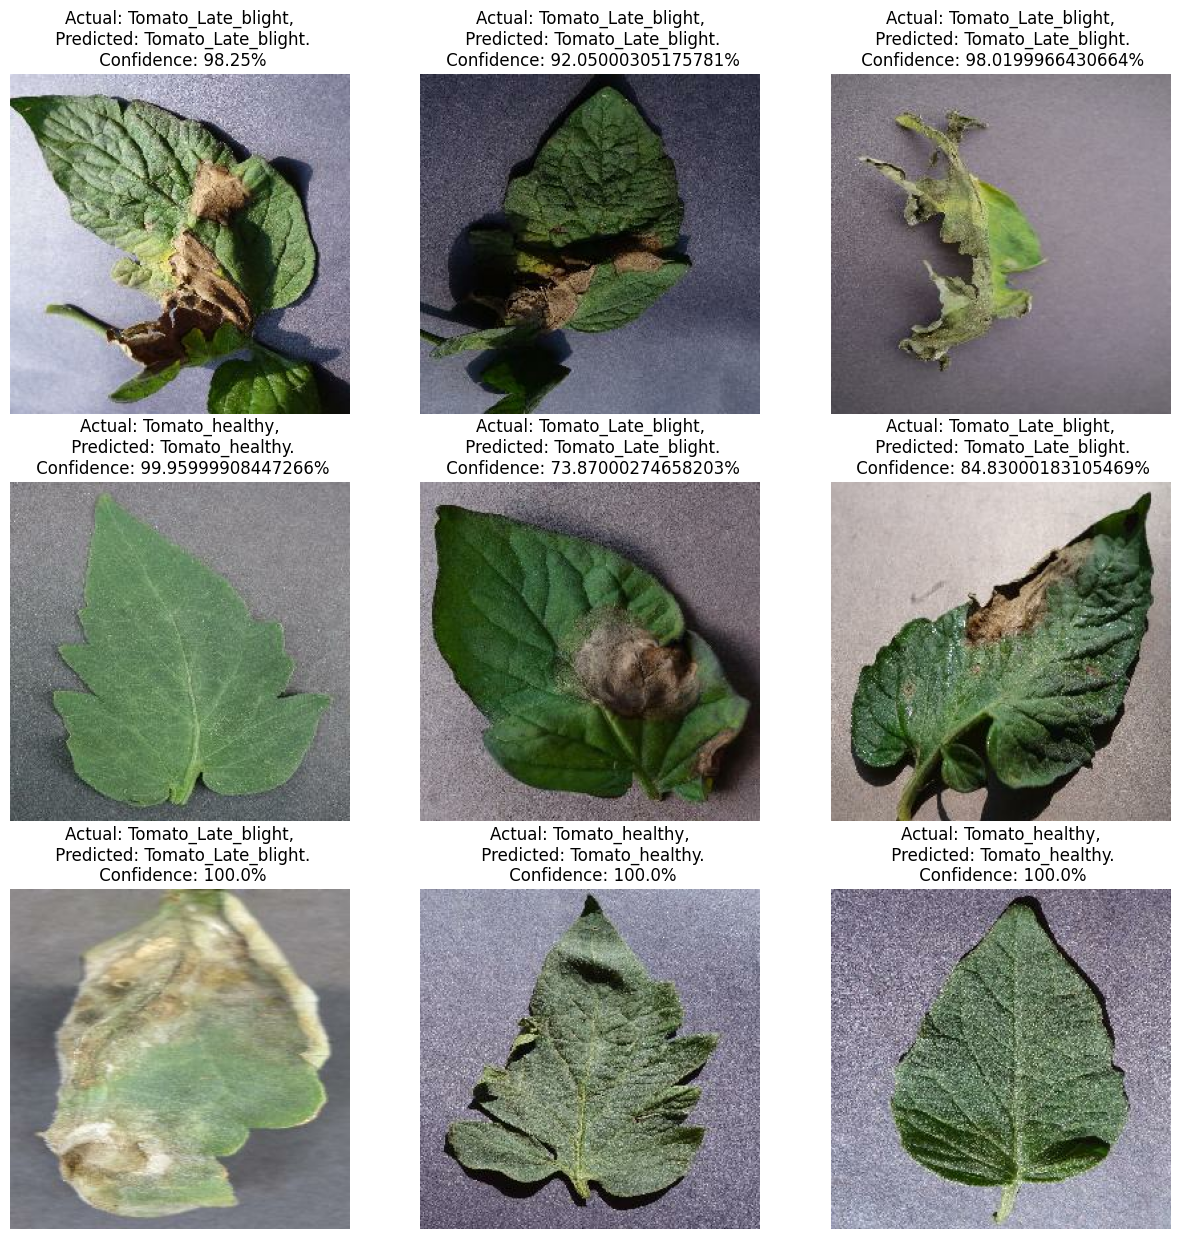

In [ ]:
# Create a figure for plotting with a specified size.
plt.figure(figsize=(15, 15))
# Iterate through one batch of the test dataset.
for images, labels in test_ds.take(1):
    # Loop through the first 9 images in the batch.
    for i in range(9):
        # Create a subplot for each image (3 rows, 3 columns).
        ax = plt.subplot(3, 3, i + 1)
        # Display the image, converting it to uint8 format.
        plt.imshow(images[i].numpy().astype("uint8"))

        # Call the predict function to get the predicted class and confidence for the current image.
        predicted_class, confidence = predict(model, images[i].numpy()) # Pass the individual image 'images[i].numpy()'
        # Get the actual class name for the current image.
        actual_class = class_names[labels[i]]

        # Set the title of the subplot to show actual, predicted class, and confidence.
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        # Turn off the axis ticks and labels.
        plt.axis("off")

### Saving the Model
We append the model to the list of models as a new version

In [ ]:
# Import the 'os' module for interacting with the operating system, like file paths.
import os

# Check if a 'models' directory exists. If not, create it.
if not os.path.exists("models"):
    os.makedirs("models")

# Get a list of files in the 'models' directory that end with ".keras",
# remove the ".keras" extension, and convert the remaining parts to integers.
files = [int(f.replace(".keras", "")) for f in os.listdir("models") if f.endswith(".keras")]

# Determine the next model version number.
# If no .keras files exist, start with 1. Otherwise, increment the maximum existing version.
model_version = max(files + [0]) + 1

# Save the trained model to Google Drive with a version number.
# The model is saved in the Keras native format.
model.save(f"/content/drive/MyDrive//Colab Notebooks/PlantVillage/models/{model_version}.keras")